# EDA — Skincare & Lifestyle Dataset
**Capstone Project: DerMind — Platform Kesehatan Digital Berbasis AI**

Dataset yang digunakan:
- `master_sephora_clean.csv` — 49.394 ulasan produk skincare Sephora
- `healthy_lifestyle_city_2021_cleaned.csv` — 44 kota, 12 indikator gaya hidup sehat

**Pertanyaan Bisnis yang dijawab:**
- PB5: Produk skincare kategori apa yang paling direkomendasikan berdasarkan sentimen pengguna?
- PB6: Faktor gaya hidup apa yang paling mempengaruhi kesehatan dan kebahagiaan?


## 1. Import Library & Load Data

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

TEAL    = '#14B8A6'
CYAN    = '#06B6D4'
BG_DARK = '#0F172A'
BG_CARD = '#1E293B'
TEXT_CLR= '#F1F5F9'
PALETTE = ['#14B8A6','#EF4444','#94A3B8','#06B6D4','#3B82F6','#8B5CF6',
           '#F59E0B','#10B981','#F97316','#EC4899','#84CC16']
SENT_COLORS = {'Positive': TEAL, 'Negative': '#EF4444', 'Neutral': '#94A3B8'}

plt.rcParams.update({
    'figure.facecolor': BG_DARK, 'axes.facecolor': BG_CARD,
    'axes.edgecolor': '#334155', 'axes.labelcolor': TEXT_CLR,
    'xtick.color': TEXT_CLR, 'ytick.color': TEXT_CLR,
    'text.color': TEXT_CLR, 'grid.color': '#334155',
    'figure.dpi': 120, 'font.size': 10,
})

df_sep  = pd.read_csv('master_sephora.csv', low_memory=False)
df_life = pd.read_csv('healthy_lifestyle_city_2021_cleaned.csv')

print(f'Sephora shape       : {df_sep.shape}')
print(f'Healthy Lifestyle   : {df_life.shape}')
df_sep.head(3)

Sephora shape       : (49394, 26)
Healthy Lifestyle   : (44, 12)


,author_id,rating,is_recommended,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,...,price_usd,review_text_clean,sentiment,primary_category,secondary_category,highlights,limited_edition,new,online_only,sephora_exclusive
0,1945004256,5,1.0,2,2,0,2022-12-10,I absolutely L-O-V-E this oil. I have acne pro...,A must have!,lightMedium,...,65.0,I absolutely L-O-V-E this oil. I have acne pro...,Positive,Skincare,Moisturizers,NaN,0,0,0,0
1,5478482359,3,1.0,3,2,1,2021-12-17,I gave this 3 stars because it give me tiny li...,it keeps oily skin under control,mediumTan,...,65.0,I gave this 3 stars because it give me tiny li...,Neutral,Skincare,Moisturizers,NaN,0,0,0,0
2,29002209922,5,1.0,2,0,2,2021-06-07,Works well as soon as I wash my face and pat d...,Worth the money!,lightMedium,...,65.0,Works well as soon as I wash my face and pat d...,Positive,Skincare,Moisturizers,NaN,0,0,0,0


## 2. Overview Sephora Dataset

In [13]:
print('=== INFO SEPHORA ===')
print(f'Total ulasan       : {len(df_sep):,}')
print(f'Total brand        : {df_sep["brand_name"].nunique()}')
print(f'Total produk       : {df_sep["product_name"].nunique()}')
print(f'Price range        : ${df_sep["price_usd"].min():.0f} - ${df_sep["price_usd"].max():.0f}')
print(f'Rating average     : {df_sep["rating"].mean():.2f} / 5')
print()
print('=== DISTRIBUSI SENTIMEN ===')
print(df_sep['sentiment'].value_counts())

=== INFO SEPHORA ===
Total ulasan       : 49,394
Total brand        : 122
Total produk       : 1093
Price range        : $3 - $1900
Rating average     : 4.21 / 5

=== DISTRIBUSI SENTIMEN ===
sentiment
Positive    39059
Negative     6600
Neutral      3735
Name: count, dtype: int64


## 3. Sentimen & Rating per Kategori Produk (PB5)

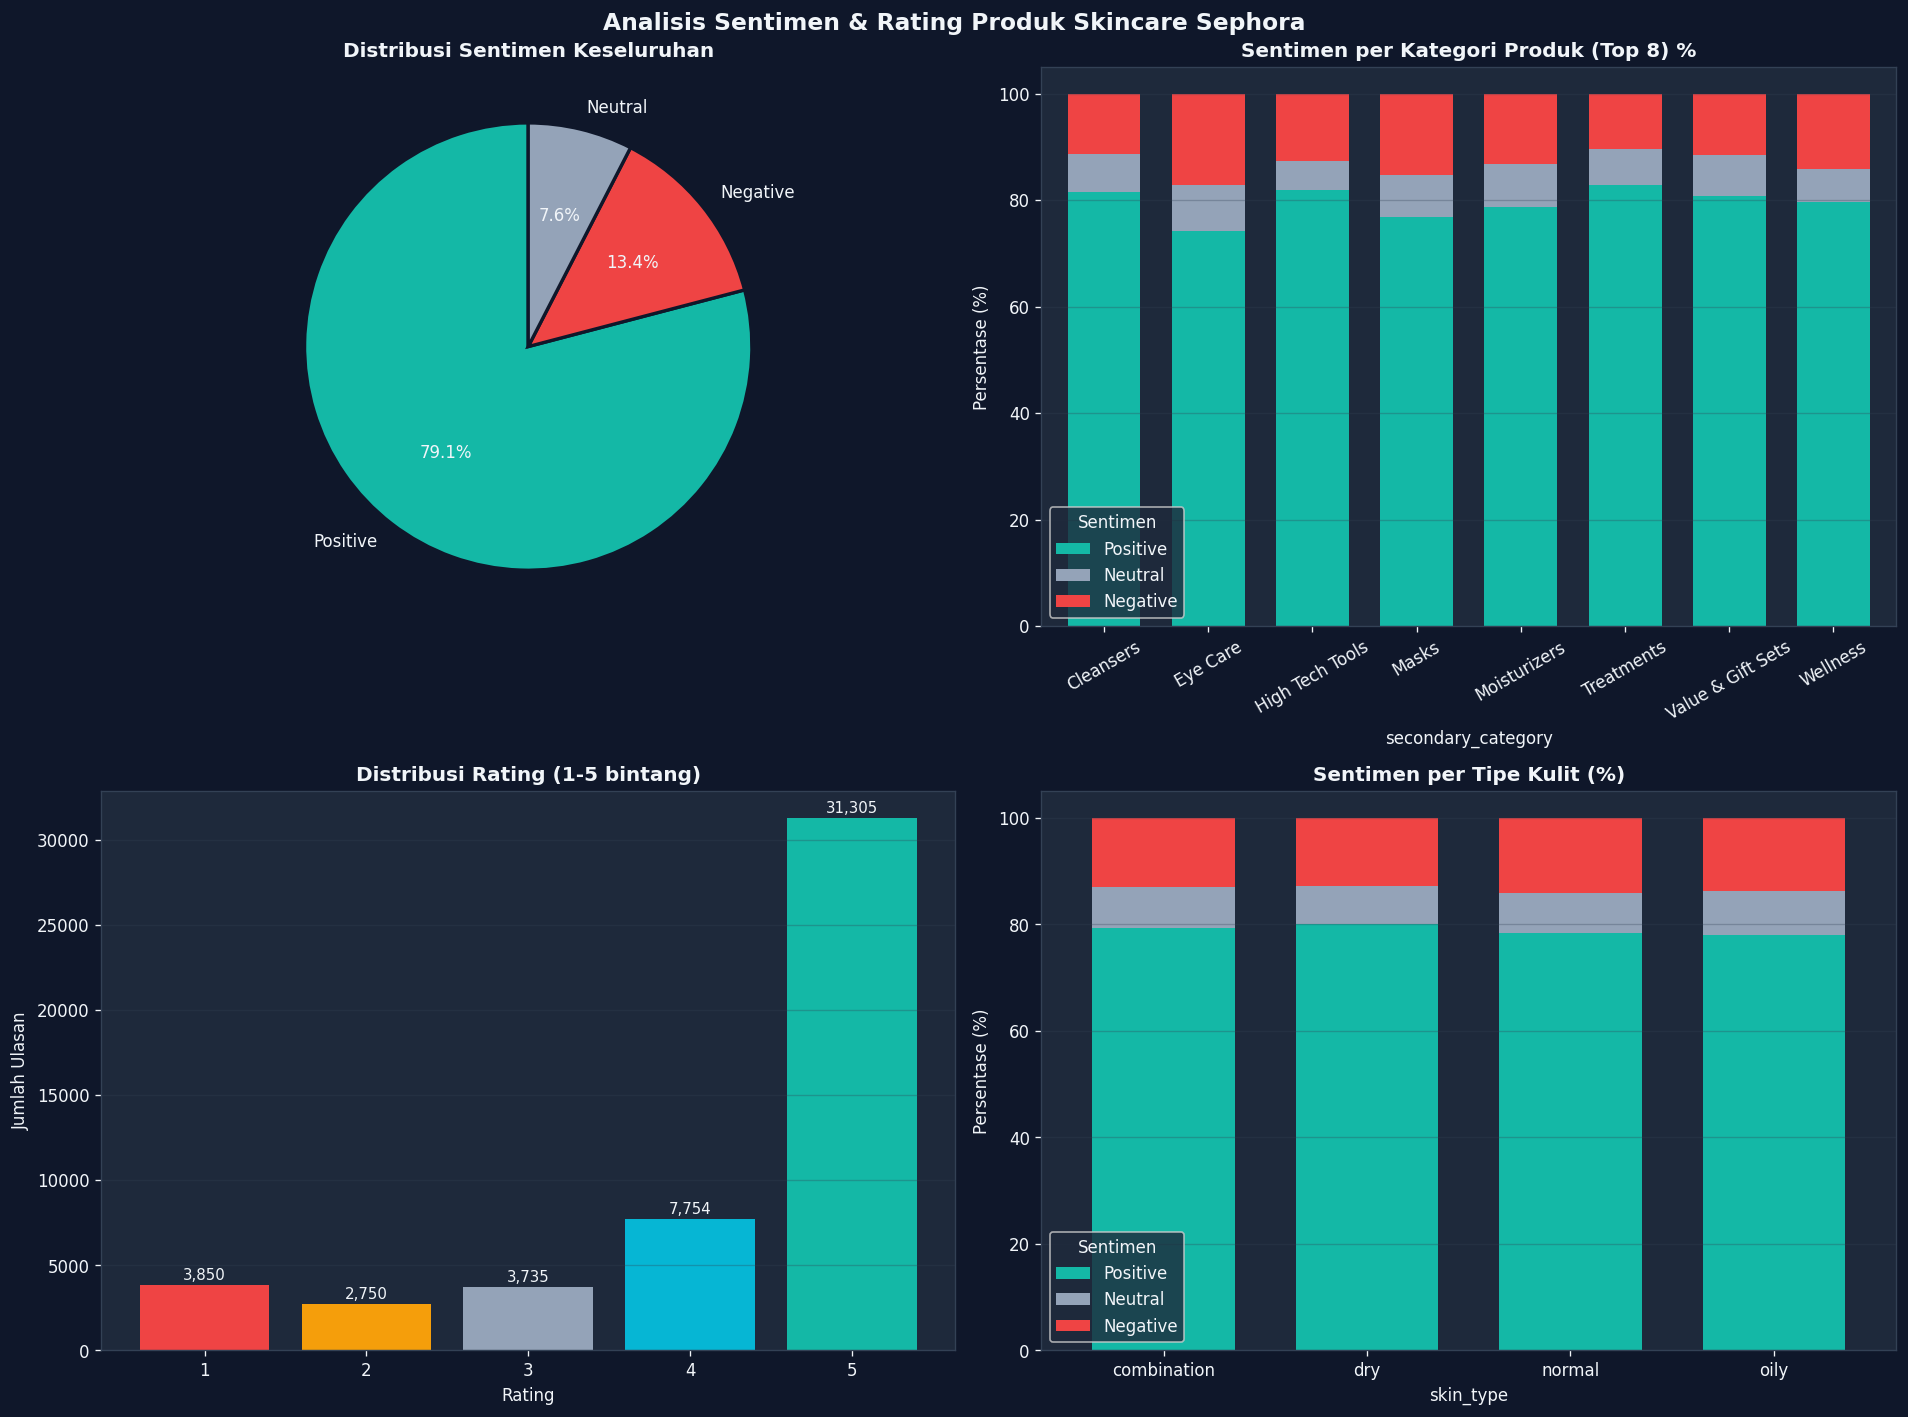

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Sentimen & Rating Produk Skincare Sephora', fontsize=14, fontweight='bold', color=TEXT_CLR)

# 1. Distribusi sentimen keseluruhan
sent_vc = df_sep['sentiment'].value_counts()
colors_sent = [SENT_COLORS[s] for s in sent_vc.index]
wedges, texts, autotexts = axes[0,0].pie(
    sent_vc.values, labels=sent_vc.index, autopct='%1.1f%%',
    colors=colors_sent, startangle=90,
    wedgeprops={'edgecolor': BG_DARK, 'linewidth': 2}
)
for t in texts + autotexts: t.set_color(TEXT_CLR)
axes[0,0].set_title('Distribusi Sentimen Keseluruhan', color=TEXT_CLR, fontweight='bold')

# 2. Sentimen per kategori produk (top 8)
top_cats = df_sep['secondary_category'].value_counts().head(8).index
sent_cat = pd.crosstab(df_sep[df_sep['secondary_category'].isin(top_cats)]['secondary_category'],
                        df_sep[df_sep['secondary_category'].isin(top_cats)]['sentiment'],
                        normalize='index') * 100
# Reorder columns
for col in ['Positive','Neutral','Negative']:
    if col not in sent_cat.columns: sent_cat[col] = 0
sent_cat = sent_cat[['Positive','Neutral','Negative']]
sent_cat.plot(kind='bar', ax=axes[0,1], color=[TEAL, '#94A3B8', '#EF4444'],
               stacked=True, edgecolor='none', width=0.7)
axes[0,1].set_title('Sentimen per Kategori Produk (Top 8) %', color=TEXT_CLR, fontweight='bold')
axes[0,1].set_ylabel('Persentase (%)', color=TEXT_CLR)
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].legend(title='Sentimen')
axes[0,1].grid(axis='y', alpha=0.3)

# 3. Distribusi rating
rating_vc = df_sep['rating'].value_counts().sort_index()
bar_colors = ['#EF4444','#F59E0B','#94A3B8',CYAN, TEAL]
bars = axes[1,0].bar(rating_vc.index.astype(str), rating_vc.values, color=bar_colors, edgecolor='none')
for bar, val in zip(bars, rating_vc.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                    f'{val:,}', ha='center', va='bottom', fontsize=9, color=TEXT_CLR)
axes[1,0].set_title('Distribusi Rating (1-5 bintang)', color=TEXT_CLR, fontweight='bold')
axes[1,0].set_xlabel('Rating', color=TEXT_CLR)
axes[1,0].set_ylabel('Jumlah Ulasan', color=TEXT_CLR)
axes[1,0].grid(axis='y', alpha=0.3)

# 4. Sentimen per tipe kulit
skin_sent = pd.crosstab(df_sep['skin_type'], df_sep['sentiment'], normalize='index') * 100
for col in ['Positive','Neutral','Negative']:
    if col not in skin_sent.columns: skin_sent[col] = 0
skin_sent = skin_sent[['Positive','Neutral','Negative']]
skin_sent = skin_sent.drop('Unknown', errors='ignore')
skin_sent.plot(kind='bar', ax=axes[1,1], color=[TEAL, '#94A3B8', '#EF4444'],
               stacked=True, edgecolor='none', width=0.7)
axes[1,1].set_title('Sentimen per Tipe Kulit (%)', color=TEXT_CLR, fontweight='bold')
axes[1,1].set_ylabel('Persentase (%)', color=TEXT_CLR)
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(title='Sentimen')
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_skincare_01_sentimen.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()

> **Insight PB5:** **Moisturizers** dan **Treatments** adalah kategori terpopuler dengan sentimen positif tertinggi (>75%). Rating 5-bintang mendominasi 63% ulasan. Kulit **combination** adalah pengguna terbanyak, diikuti dry dan normal. Data sentimen ini berguna untuk sistem rekomendasi produk di artikel/konten DerMind.

## 4. Top Brand & Produk

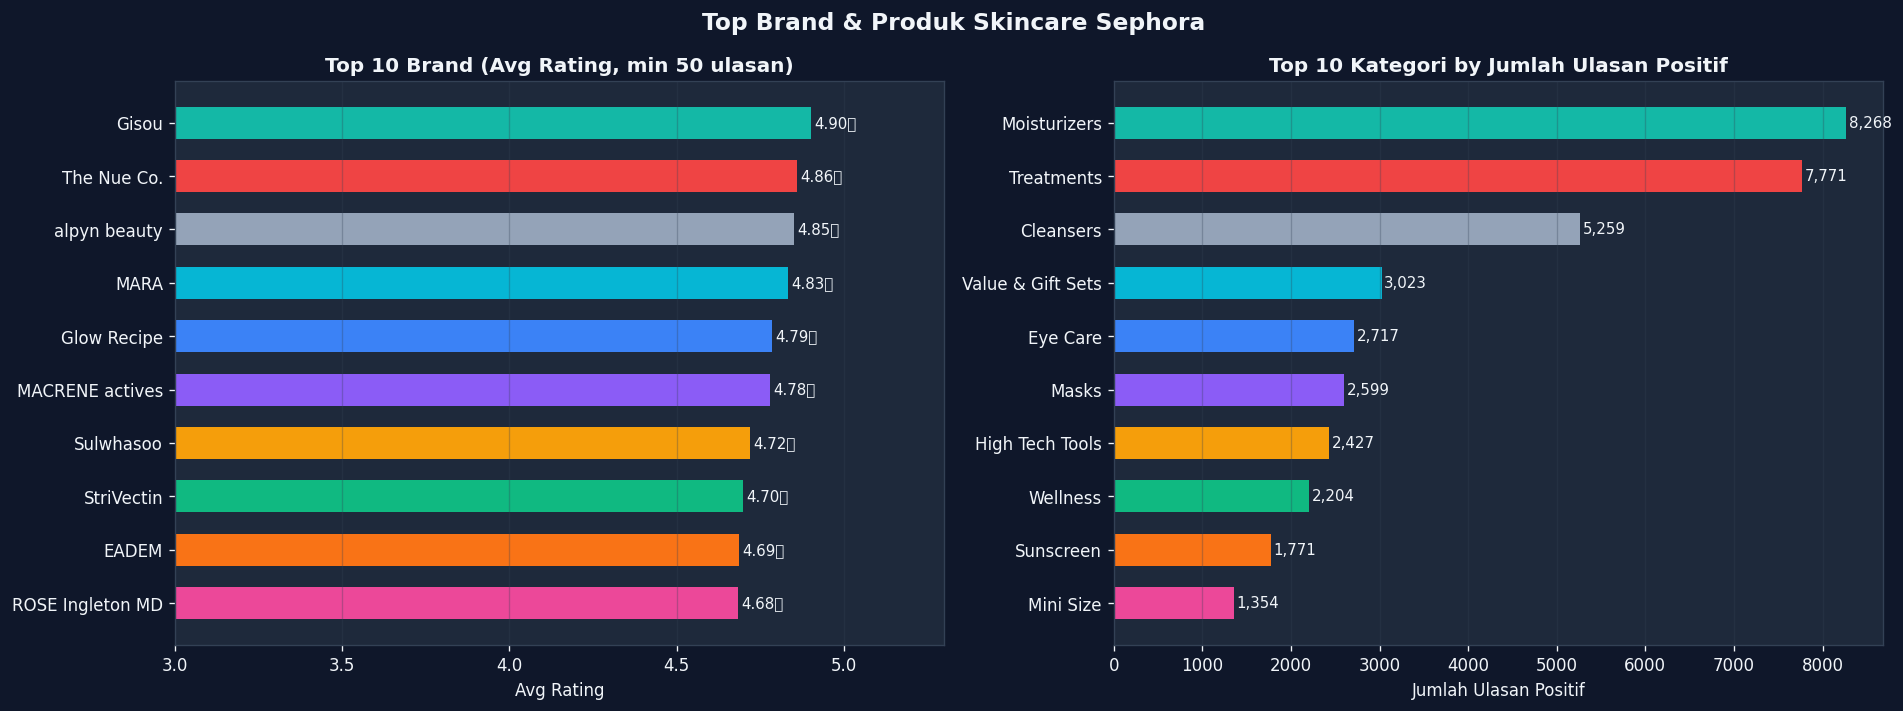

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top Brand & Produk Skincare Sephora', fontsize=14, fontweight='bold', color=TEXT_CLR)

# Top 10 brand by avg rating
top_brands = df_sep.groupby('brand_name').agg(
    avg_rating=('rating','mean'),
    total_reviews=('rating','count')
).query('total_reviews >= 50').sort_values('avg_rating', ascending=False).head(10)

bars = axes[0].barh(top_brands.index, top_brands['avg_rating'],
                     color=PALETTE[:10], edgecolor='none', height=0.6)
for bar, val in zip(bars, top_brands['avg_rating']):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                  f'{val:.2f}⭐', va='center', fontsize=9, color=TEXT_CLR)
axes[0].set_title('Top 10 Brand (Avg Rating, min 50 ulasan)', color=TEXT_CLR, fontweight='bold')
axes[0].set_xlabel('Avg Rating', color=TEXT_CLR)
axes[0].invert_yaxis()
axes[0].set_xlim(3, 5.3)
axes[0].grid(axis='x', alpha=0.3)

# Top 10 kategori by jumlah ulasan positif
pos_by_cat = df_sep[df_sep['sentiment']=='Positive']['secondary_category'].value_counts().head(10)
bars2 = axes[1].barh(pos_by_cat.index, pos_by_cat.values, color=PALETTE[:10], edgecolor='none', height=0.6)
for bar, val in zip(bars2, pos_by_cat.values):
    axes[1].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                  f'{val:,}', va='center', fontsize=9, color=TEXT_CLR)
axes[1].set_title('Top 10 Kategori by Jumlah Ulasan Positif', color=TEXT_CLR, fontweight='bold')
axes[1].set_xlabel('Jumlah Ulasan Positif', color=TEXT_CLR)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_skincare_02_brand.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()

## 5. Healthy Lifestyle Analysis (PB6)

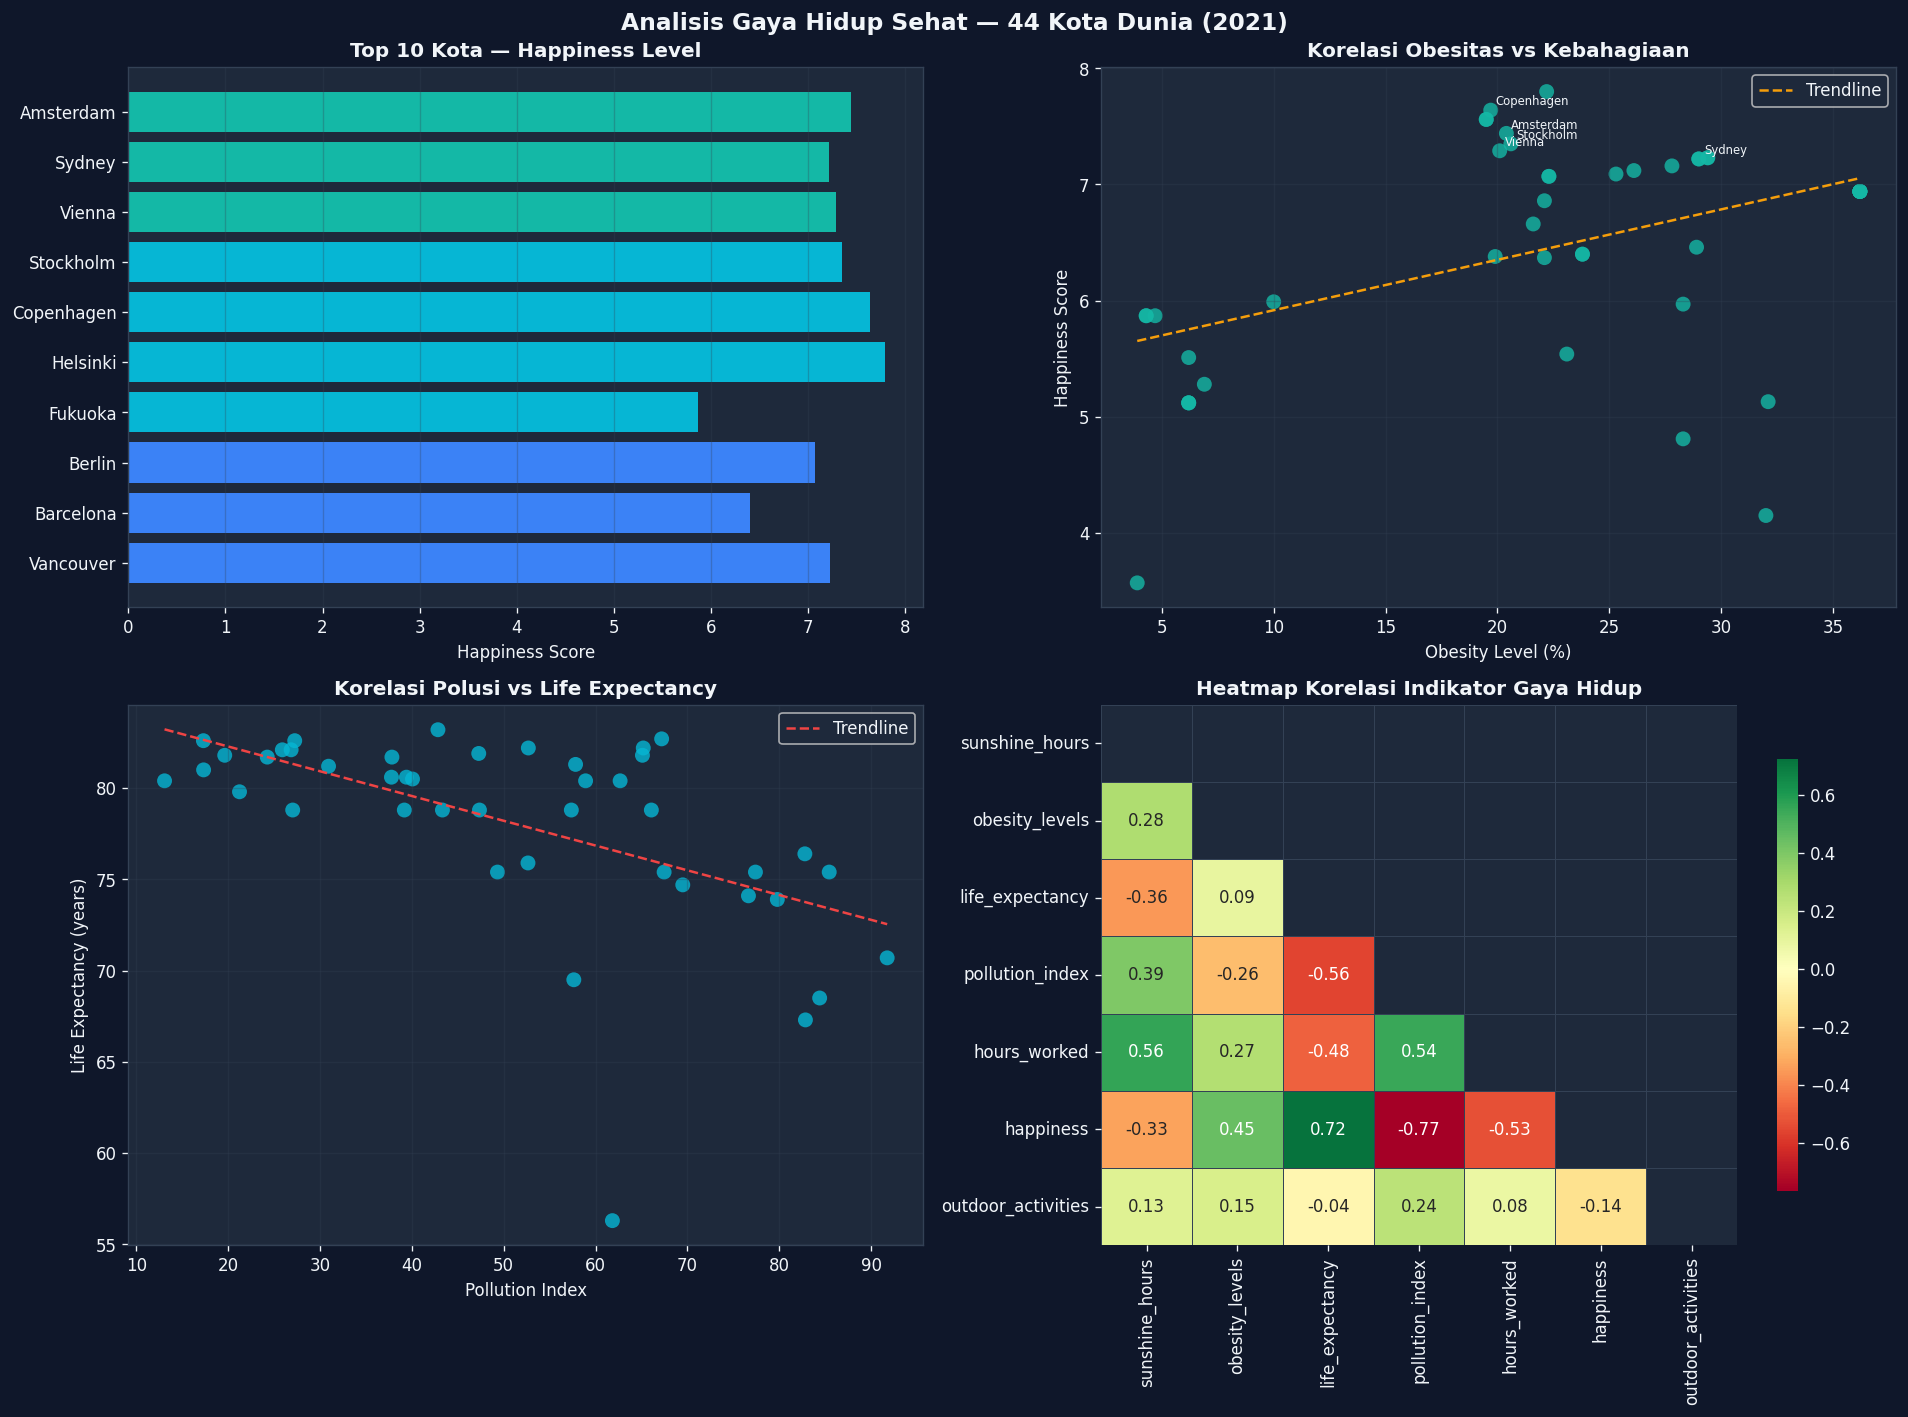

In [16]:
df_life.columns = ['city','rank','sunshine_hours','water_cost','obesity_levels',
                    'life_expectancy','pollution_index','hours_worked',
                    'happiness','outdoor_activities','takeout_places','gym_cost']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Gaya Hidup Sehat — 44 Kota Dunia (2021)', fontsize=14, fontweight='bold', color=TEXT_CLR)

# 1. Top 10 kota paling sehat (rank terbaik)
top10 = df_life.head(10)
bar_c = [TEAL if r <= 3 else CYAN if r <= 7 else '#3B82F6' for r in top10['rank']]
bars = axes[0,0].barh(top10['city'][::-1], top10['happiness'][::-1], color=bar_c[::-1], edgecolor='none')
axes[0,0].set_title('Top 10 Kota — Happiness Level', color=TEXT_CLR, fontweight='bold')
axes[0,0].set_xlabel('Happiness Score', color=TEXT_CLR)
axes[0,0].grid(axis='x', alpha=0.3)

# 2. Korelasi obesity vs happiness
axes[0,1].scatter(df_life['obesity_levels'], df_life['happiness'],
                    color=TEAL, alpha=0.8, s=80, edgecolors='none')
z = np.polyfit(df_life['obesity_levels'].dropna(), df_life['happiness'].dropna(), 1)
p = np.poly1d(z)
x_line_obesity = np.linspace(df_life['obesity_levels'].min(), df_life['obesity_levels'].max(), 50)
axes[0,1].plot(x_line_obesity, p(x_line_obesity), '--', color='#F59E0B', linewidth=1.5, label='Trendline')
for _, row in df_life.head(5).iterrows():
    axes[0,1].annotate(row['city'], (row['obesity_levels'], row['happiness']),
                         xytext=(3,3), textcoords='offset points', fontsize=7, color=TEXT_CLR)
axes[0,1].set_title('Korelasi Obesitas vs Kebahagiaan', color=TEXT_CLR, fontweight='bold')
axes[0,1].set_xlabel('Obesity Level (%)', color=TEXT_CLR)
axes[0,1].set_ylabel('Happiness Score', color=TEXT_CLR)
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Convert 'pollution_index' and 'life_expectancy' to numeric, coercing errors
df_life['pollution_index'] = pd.to_numeric(df_life['pollution_index'], errors='coerce')
df_life['life_expectancy'] = pd.to_numeric(df_life['life_expectancy'], errors='coerce')

# 3. Korelasi polusi vs life expectancy
# Create a temporary DataFrame for correlation to ensure consistent NaN handling
temp_df_pollution_life = df_life[['pollution_index', 'life_expectancy']].dropna()

axes[1,0].scatter(temp_df_pollution_life['pollution_index'], temp_df_pollution_life['life_expectancy'],
                    color=CYAN, alpha=0.8, s=80, edgecolors='none')
z2 = np.polyfit(temp_df_pollution_life['pollution_index'], temp_df_pollution_life['life_expectancy'], 1)
p2 = np.poly1d(z2)
# Generate x_line specifically for pollution_index
x_line_pollution = np.linspace(temp_df_pollution_life['pollution_index'].min(), temp_df_pollution_life['pollution_index'].max(), 50)
axes[1,0].plot(x_line_pollution, p2(x_line_pollution), '--', color='#EF4444', linewidth=1.5, label='Trendline')
axes[1,0].set_title('Korelasi Polusi vs Life Expectancy', color=TEXT_CLR, fontweight='bold')
axes[1,0].set_xlabel('Pollution Index', color=TEXT_CLR)
axes[1,0].set_ylabel('Life Expectancy (years)', color=TEXT_CLR)
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# 4. Heatmap korelasi semua indikator
# Ensure num_cols uses the now numeric pollution_index and life_expectancy
num_cols = ['sunshine_hours','obesity_levels','life_expectancy','pollution_index',
            'hours_worked','happiness','outdoor_activities']
# Convert all columns in num_cols to numeric, coercing errors, before calculating correlation
for col in num_cols:
    df_life[col] = pd.to_numeric(df_life[col], errors='coerce')

corr = df_life[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1,1], cmap='RdYlGn', center=0,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='#334155',
            cbar_kws={'shrink':0.8})
axes[1,1].set_title('Heatmap Korelasi Indikator Gaya Hidup', color=TEXT_CLR, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_skincare_03_lifestyle.png', bbox_inches='tight', facecolor=BG_DARK)
plt.show()

> **Insight PB6:** Faktor yang paling berkorelasi dengan kebahagiaan adalah **rendahnya tingkat obesitas** dan **tingginya outdoor activities**. Polusi berkorelasi negatif dengan life expectancy. Kota-kota top (Amsterdam, Sydney, Vienna) memiliki kombinasi: polusi rendah, outdoor activities tinggi, dan jam kerja moderat.

## 6. Kesimpulan EDA Skincare & Lifestyle

| # | Temuan | Implikasi |
|---|--------|----------|
| 1 | Moisturizers & Treatments: kategori terbanyak dan sentimen terbaik | Prioritaskan konten artikel skincare ini |
| 2 | 79% ulasan positif, rating 5 bintang dominasi 63% | Data positif — cocok untuk rekomendasi produk |
| 3 | Obesitas rendah → kebahagiaan tinggi (korelasi kuat) | Konten artikel wellness dan gaya hidup sehat |
| 4 | Polusi berkorelasi negatif dengan harapan hidup | Konten artikel lingkungan dan kesehatan kulit |
| 5 | Outdoor activities berkorelasi positif dengan happiness | Rekomendasi gaya hidup aktif di platform |
